# Dimension Reduction

* reduce "noise" in data
* reduce size of data

## PCA - Principal Component Analysis

1. Decorrleate data
1. Reduce dimensionality

In the essence this is a linear transformation of the data to a new coordinate system.

* Rotating the data so that the axes align with the directions of maximum variance
* Shift the data so that the mean is zero

> Note: There is no loss of information in this transformation

In [35]:
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine()

# extract 'total_phenols' and 'od280/od315_of_diluted_wines' into samples
raw_samples = wine.data[:, [6, 12]]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
samples = scaler.fit_transform(raw_samples)

# create dataframe
df = pd.DataFrame(samples, columns=['total_phenols', 'od280'])
print(df.head())

   total_phenols     od280
0       1.034819  1.013009
1       0.733629  0.965242
2       1.215533  1.395148
3       1.466525  2.334574
4       0.663351 -0.037874


In [36]:
# create array from samples
samples = df.values

## Measure the correlation of the features

PCA should decorrelate the features. We can measure the correlation of the features using the Pearson correlation coefficient.

Pearson has values between -1 and 1. 1 is a perfect positive correlation, -1 is a perfect negative correlation and 0 is no correlation.

In [37]:
from scipy.stats import pearsonr

# calculate correlation between 'total_phenols' and 'od280'
total_phenols = samples[:, 0]
od280 = samples[:, 1]

correlation, pvalue = pearsonr(total_phenols, od280)
print("correlation: ", correlation)

correlation:  0.4941931272043738


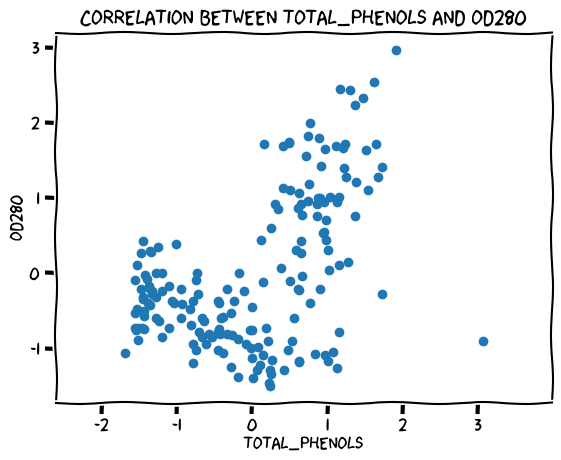

In [38]:
# Visualize the correlation

from matplotlib import pyplot as plt
plt.xkcd()

plt.title('Correlation between total_phenols and od280')
plt.xlabel('total_phenols')
plt.ylabel('od280')
plt.axis('equal') # make the x and y axes equal in scale to show the true shape of the data
plt.scatter(total_phenols, od280)
plt.show()

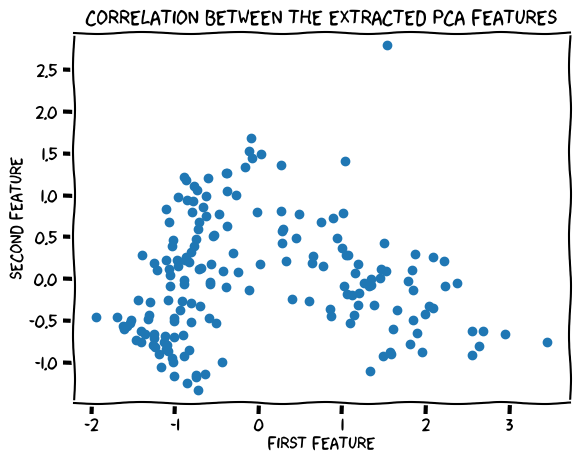

In [39]:
from sklearn.decomposition import PCA

model = PCA()
pca_features = model.fit_transform(samples)

plt.title('Correlation between the extracted PCA features')
plt.xlabel('first feature')
plt.ylabel('second feature')
plt.axis('equal') # make the x and y axes equal in scale to show the true shape of the data
plt.scatter(pca_features[:, 0], pca_features[:, 1])
plt.show()